# Data visualization and classification in `scikit-learn` & `matplotlib`

In [4]:
# Check for all needed packages
import numpy
import matplotlib
import mnists
import sklearn
import plotly
import nbformat
# In case of ImportError, install them to the running kernel with
# %pip install numpy matplotlib mnists scikit-learn plotly nbformat
# or the the runtime container with:
# !pip install numpy matplotlib mnists scikit-learn plotly nbformat
# (In case of the latter, remember to restart the kernel!)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1234)

try:
    import mkl
    mkl.set_num_threads(2)
except ImportError:
    print("Intel Math Kernel Library (MKL) does not always work on every machine. "
          "Continuing without `mkl`.")

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams["figure.figsize"] = [16, 9]

Intel Math Kernel Library (MKL) does not always work on every machine. Continuing without `mkl`.


In [6]:
def arrange_tiles_img(examples: np.array) -> np.array:
    """
    Arrange 2D matrices as tiles

    Takes 4D `examples` tensor with dims:
        rows x cols x tile_height x tile_width
    """
    rows_count = examples.shape[0]
    cols_count = examples.shape[1]
    tile_height = examples.shape[2]
    tile_width = examples.shape[3]
    
    space_between_tiles = 2 # [px]
    
    img_height = rows_count * tile_height + (rows_count -1) * space_between_tiles
    img_width = cols_count * tile_width + (cols_count -1) * space_between_tiles
    
    
    img_matrix = np.empty(shape=(img_height, img_width))
    img_matrix.fill(np.nan)
    
    for r in range(rows_count):
        for c in range(cols_count):
            row_start = r * (tile_height + space_between_tiles)
            col_start = c * (tile_width + space_between_tiles)
    
            img_matrix[
                row_start:row_start + tile_height,
                col_start:col_start + tile_width
            ] = examples[r, c]

    
    return img_matrix


## MNIST Dataset

Import and visualistion of the MNIST dataset with the auxiliary `arrange_tiles_img()` function.

/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/mnists/MNIST/train-images-idx3-ubyte.gz: 100%|██████████| 9.46M/9.46M [00:02<00:00, 3.97MB/s]


/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/mnists/MNIST/train-labels-idx1-ubyte.gz: 100%|██████████| 32.0k/32.0k [00:00<00:00, 92.6kB/s]


/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/mnists/MNIST/t10k-images-idx3-ubyte.gz: 100%|██████████| 1.58M/1.58M [00:00<00:00, 1.73MB/s]


/var/folders/l1/7bh364895gg8nssghh2l23dh0000gn/T/mnists/MNIST/t10k-labels-idx1-ubyte.gz: 100%|██████████| 8.00k/8.00k [00:00<00:00, 19.1kB/s]


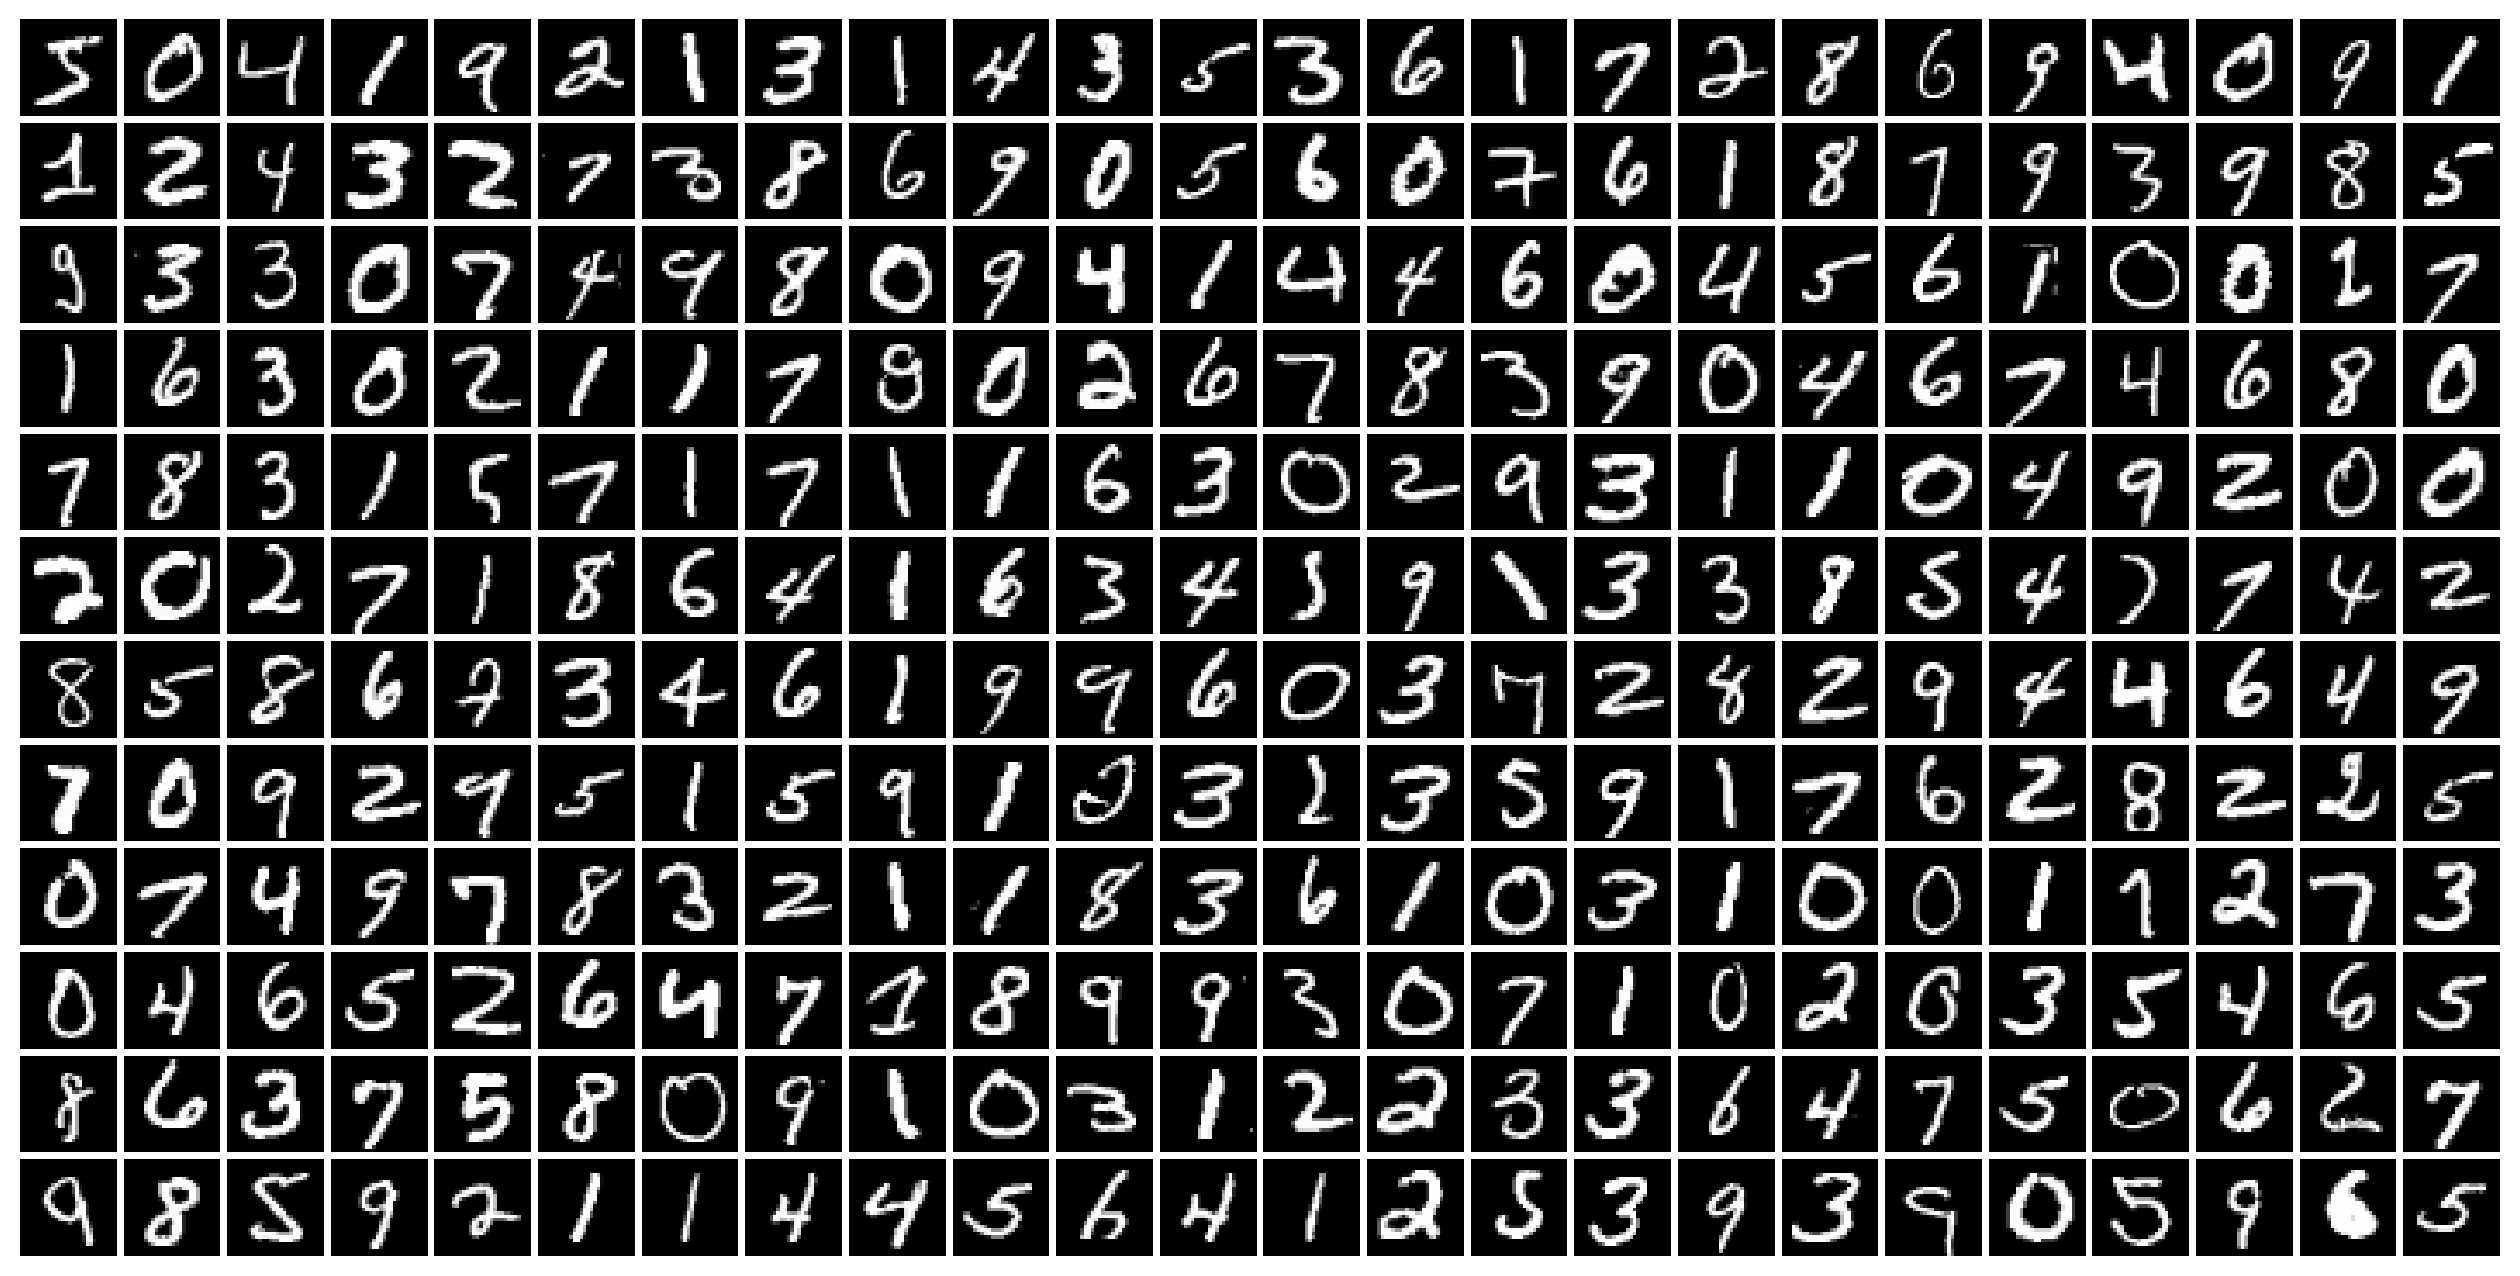

In [7]:
from mnists import MNIST
mnist = MNIST()

n_rows = 12
n_cols = 24
tile_dim = 28 # [px]
shape = (n_rows, n_cols, tile_dim, tile_dim)
mnist_digits = np.reshape(mnist.train_images()[:12*24], shape=shape)

tiles_img = arrange_tiles_img(mnist_digits)

plt.matshow(tiles_img, cmap='gray', interpolation='none')
plt.axis('off')
plt.show()

In [8]:
X = mnist.train_images().astype(np.float32) / 255.0 # Data normalization from [0, 255] to [0.0, 1.0]
y = mnist.train_labels()
X.shape

(60000, 28, 28)

Reshape `X` so that the last two dimensions are collapsed into single dimension.

In [12]:
# TODO: Reshape X
X = X.reshape(X.shape[0], -1)

In [13]:
X.shape

(60000, 784)

## Visualizing the distribution of MNIST digits

Add a scatter plot to `plot`, which:
* displys the first two dimensions of `X`,
* includes only these elements from `X` for which `y == i` (i.e. elements from the i-th class),
* includes label (i.e. `i`) in the legend.


In [16]:
def plot_2d_mnist_scatter(X: np.array, y: np.array) -> None:
    fig, plot = plt.subplots()
    fig.set_size_inches(16, 16)
    plt.prism()

    for i in range(10):
        digit_indeces = y == i
        dim1 = X[digit_indeces, 0]
        dim2 = X[digit_indeces, 1]
        plot.scatter(dim1, dim2, label=i, alpha=0.6)

    plot.set_xticks(())
    plot.set_yticks(())

    plt.tight_layout()
    plt.legend()
    plt.show()

### Principal Component Analysis (PCA)

In [17]:
# Creating a small subset of the MNIST dataset for faster preview computation
SAMPLES_LIMIT = 2000
X_small = X[:SAMPLES_LIMIT]
y_small = y[:SAMPLES_LIMIT]

Use PCA function to embed `X_small` in two dimensions. Store the result in `X_pca_embedded`.

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca_embedded = pca.fit_transform(X_small)

In [19]:
X_pca_embedded.shape

(2000, 2)

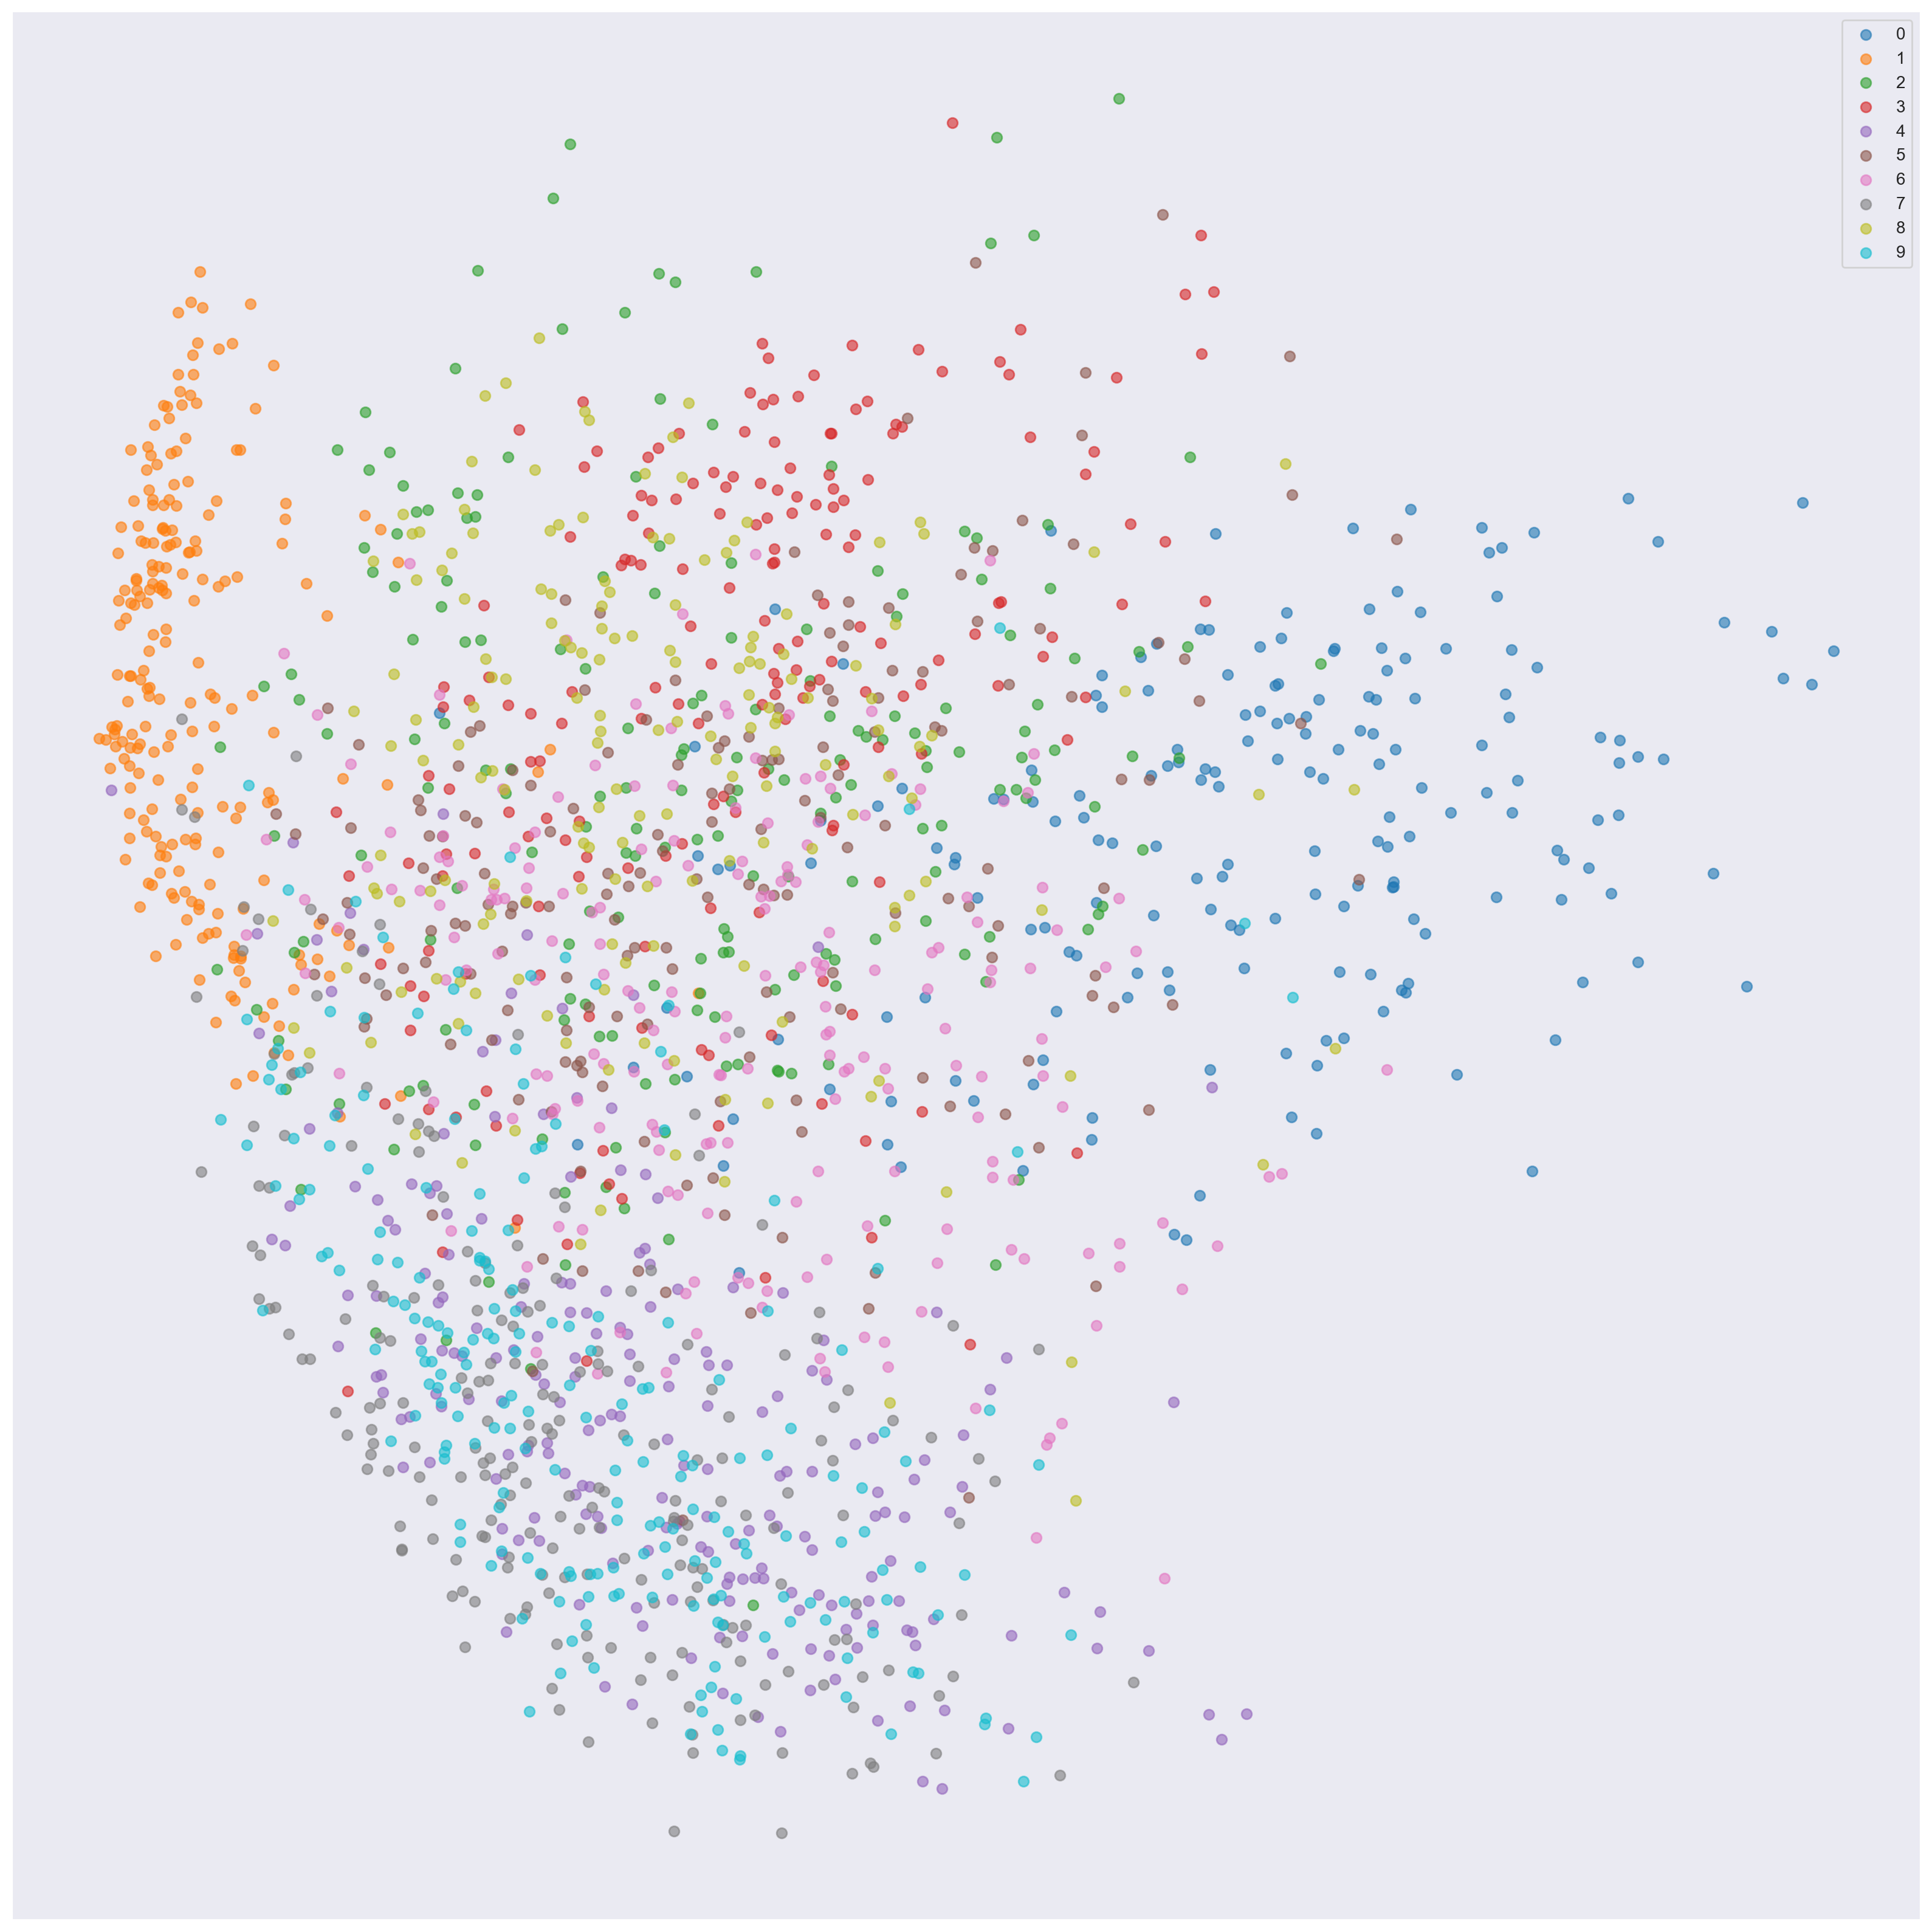

In [20]:
plot_2d_mnist_scatter(X_pca_embedded, y_small)

### T-distributed Stochastic Neighbour Embedding (T-SNE)

Make sure to have a look on this increadible [article on T-SNE](https://distill.pub/2016/misread-tsne/).

Use `T-SNE` function to embed `X_small` in two dimensions. Store the result in `X_tsne_embedded`. <BR>
Use:
 * `n_components=2` argument to setup the dimension of the embedded space,
 * `n_iter=500` or `max_iter=500` argument to limit the number of T-SNE iterations, 
 * `verbose=2` argument to see a verbose output during embedding.

In [21]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=1234)
X_tsne_embedded = tsne.fit_transform(X_small)

In [22]:
X_tsne_embedded.shape

(2000, 2)

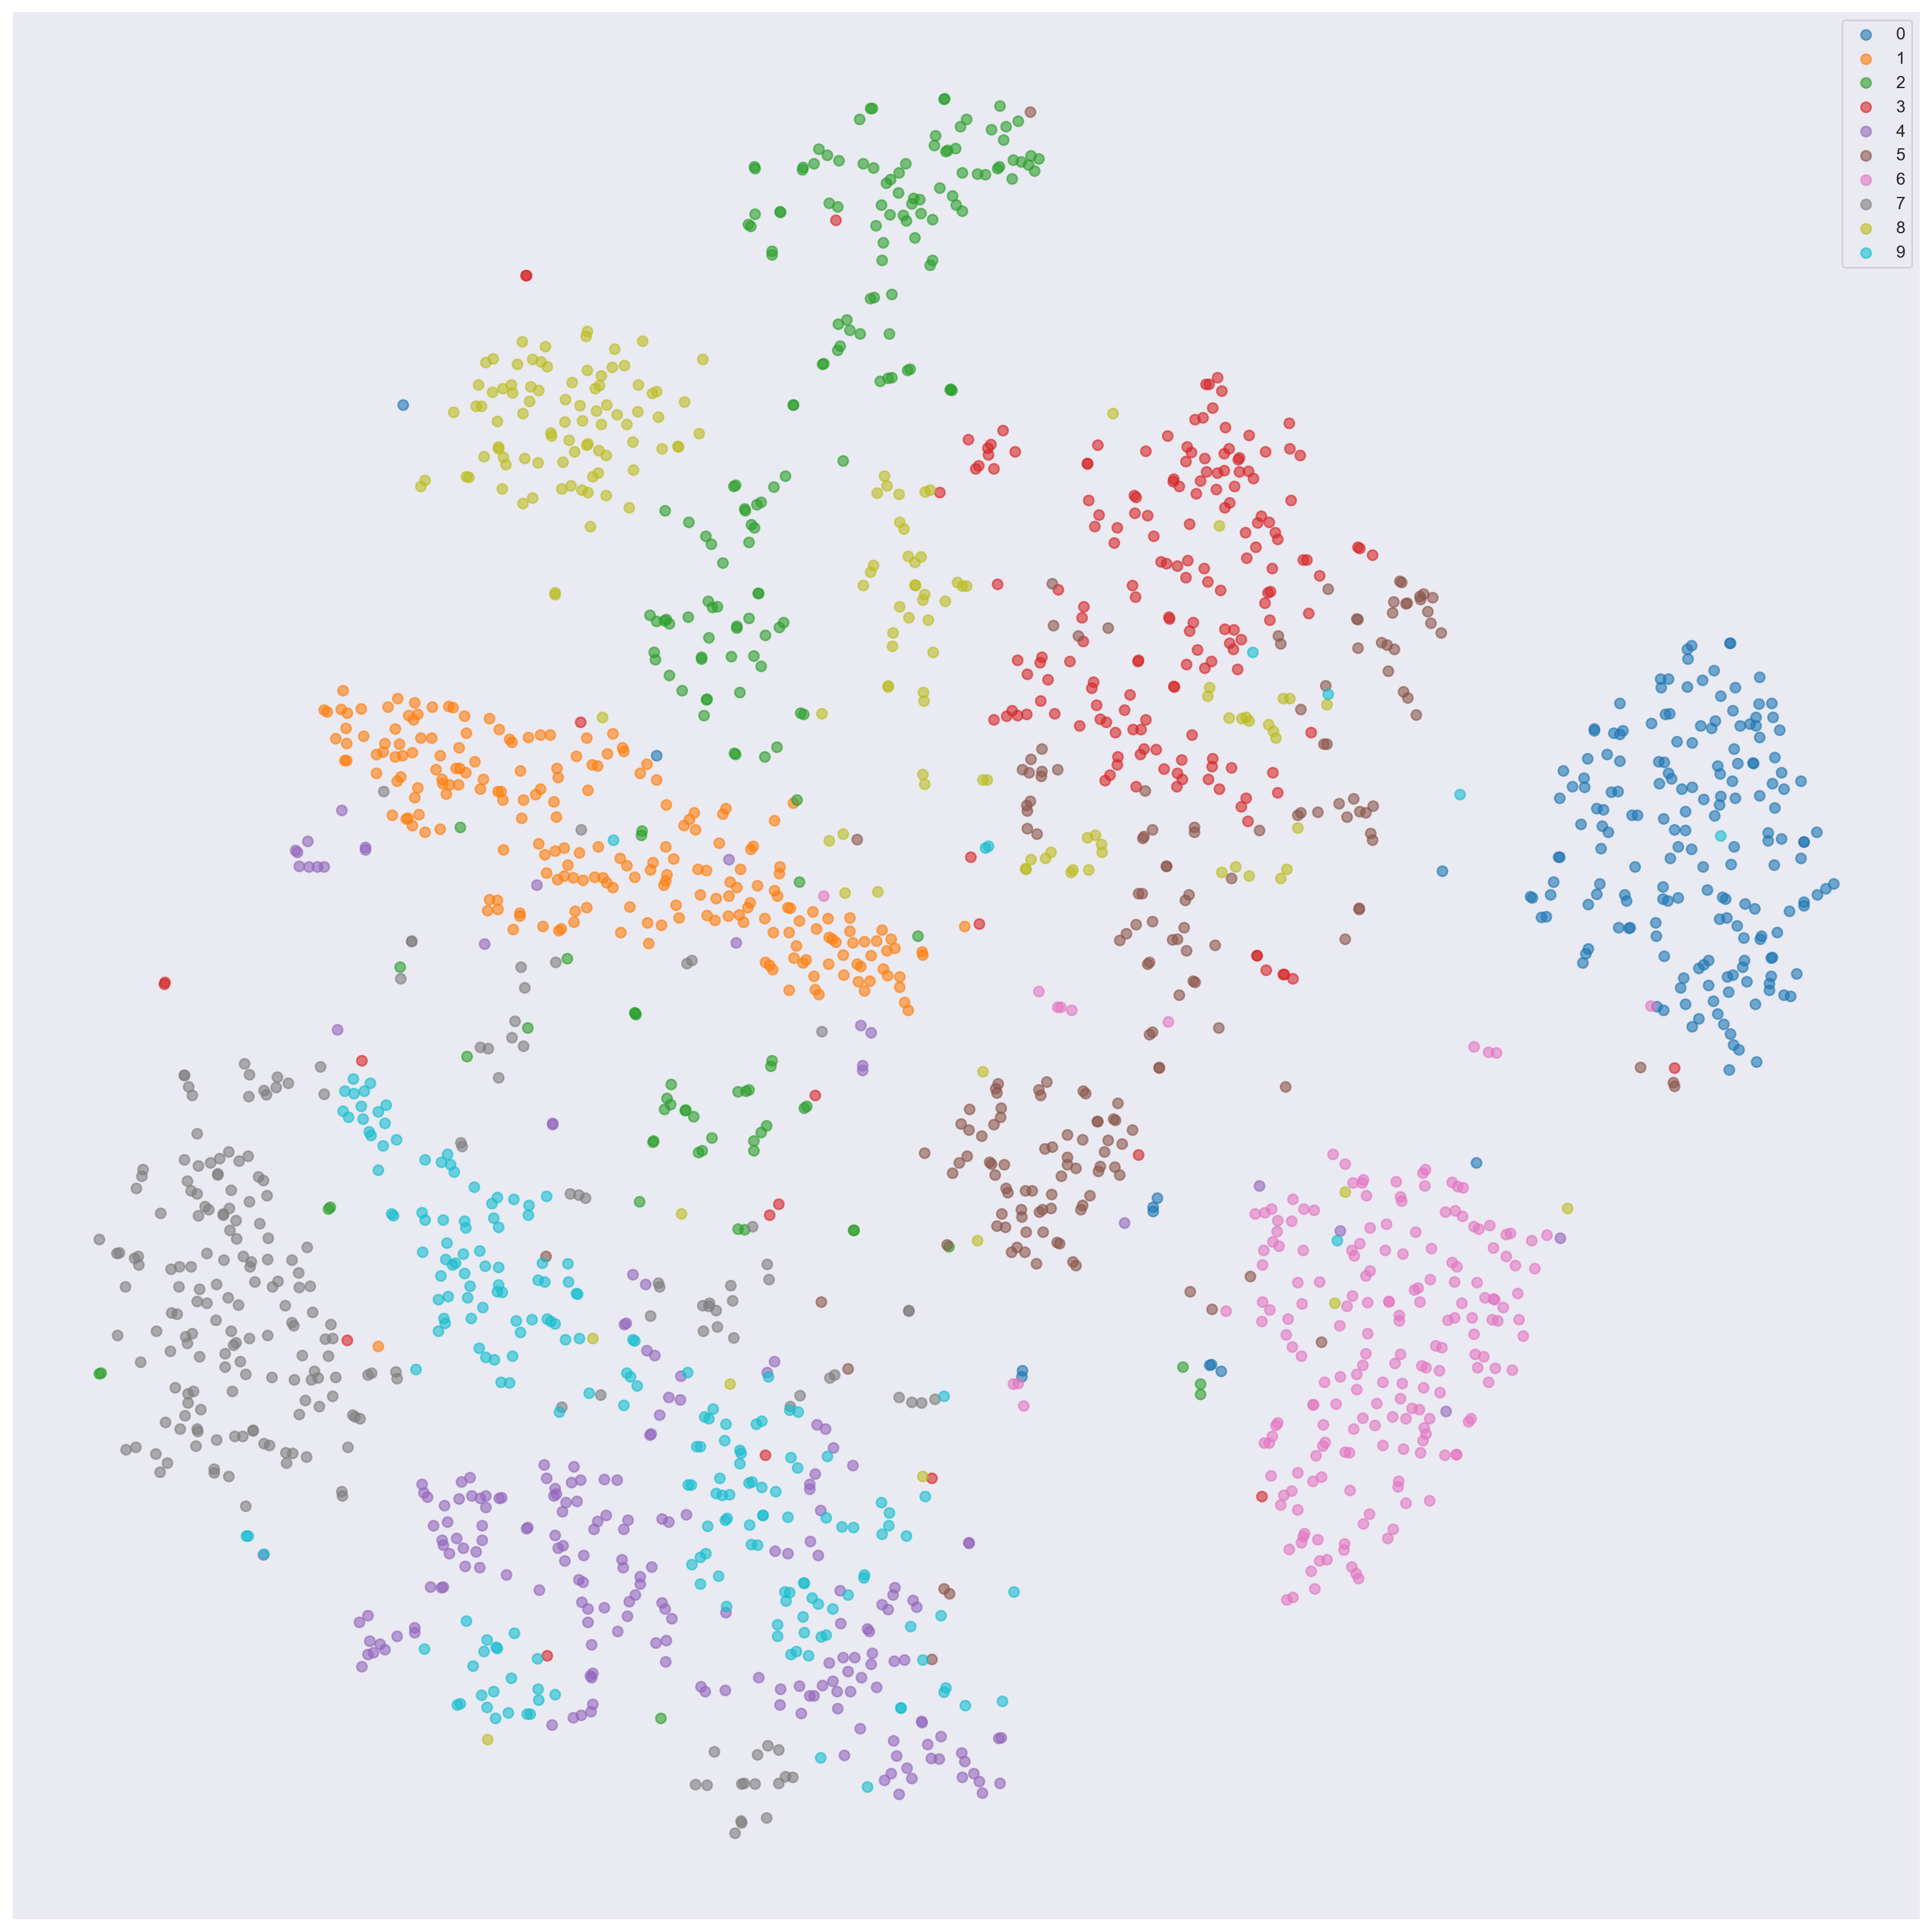

In [23]:
plot_2d_mnist_scatter(X_tsne_embedded, y_small)

### 3D interactive plots with plotly

In [24]:
import plotly.io as pio

def detect_and_set_plotly_renderer() -> str:
    """
    Helper function that sniffs the environment and sets the right renderer
    """
    try:
        shell = get_ipython().__class__
        shell_name = shell.__name__
        module = shell.__module__

        if "google.colab" in module:
            renderer = "colab"
        elif shell_name == "ZMQInteractiveShell":
            # Could be Jupyter Notebook or JupyterLab
            try:
                import jupyterlab
                renderer = "iframe"  # JupyterLab
            except ImportError:
                renderer = "notebook"  # Classic Jupyter Notebook
        elif shell_name == "TerminalInteractiveShell":
            renderer = "browser"  # Plain IPython terminal
        else:
            # VS Code, Databricks, etc.
            import os
            if "VSCODE_PID" in os.environ or "VSCODE_CWD" in os.environ:
                renderer = "notebook"  # VS Code
            elif "DATABRICKS_RUNTIME_VERSION" in os.environ:
                renderer = "databricks"
            else:
                renderer = "iframe"  # safe fallback
    except NameError:
        renderer = "browser"  # plain Python script

    pio.renderers.default = renderer
    print(f"Detected renderer: '{renderer}'")

detect_and_set_plotly_renderer()

Detected renderer: 'iframe'


In [25]:
import plotly.graph_objs as go

def plot_3d_mnist_plotly_scatter(X, y):
    def make_trace(i):
        digit_indices = y == i
        return go.Scatter3d(
            x=X[digit_indices, 0],
            y=X[digit_indices, 1],
            z=X[digit_indices, 2],
            mode='markers',
            name=str(i),
            marker=dict(
                color=i,
                colorscale='Jet',
                size=4,
                symbol='circle',
                line=dict(color='rgb(204, 204, 204)', width=1)
            )
        )

    traces = [make_trace(i) for i in range(10)]
    layout = go.Layout(margin=dict(l=0, r=0, b=0, t=0))
    fig = go.Figure(data=traces, layout=layout)
    fig.show()  # ← key change

Use PCA function to embed `X_small` in **three** dimensions. Store the result in `X_3d_pca_embedded`.

In [26]:
pca_3d = PCA(n_components=3)
X_3d_pca_embedded = pca_3d.fit_transform(X_small)

plot_3d_mnist_plotly_scatter(X_3d_pca_embedded, y_small)

In [27]:
X_3d_pca_embedded.shape

(2000, 3)

In [28]:
plot_3d_mnist_plotly_scatter(X_3d_pca_embedded, y_small)

## Classification task (with SVM)
SVM - Support Vector Machine

In [29]:
from sklearn.model_selection import train_test_split
SAMPLES_LIMIT=10000
X_train, X_test, y_train, y_test = train_test_split(X[:SAMPLES_LIMIT], y[:SAMPLES_LIMIT], test_size=0.2)

In [30]:
from sklearn import svm
classifier = svm.SVC(C=1, gamma=0.001)
classifier.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [31]:
from sklearn import metrics

predicted = classifier.predict(X_test)

print(f"Classification report for classifier {classifier}:\n{metrics.classification_report(y_test, predicted)}\n")

Classification report for classifier SVC(C=1, gamma=0.001):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       192
           1       0.89      0.99      0.94       235
           2       0.93      0.88      0.91       209
           3       0.87      0.81      0.84       192
           4       0.92      0.95      0.93       212
           5       0.87      0.88      0.87       174
           6       0.96      0.96      0.96       202
           7       0.91      0.93      0.92       205
           8       0.92      0.84      0.88       187
           9       0.89      0.89      0.89       192

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000




Calculate and display the confision matrix for `predicted` and `y_test` (use metrics package).

In [32]:
# TODO: Calculate confusion matrix

confusion_matrix = metrics.confusion_matrix(y_test, predicted)
print(f"Confusion matrix:\n{confusion_matrix}")

Confusion matrix:
[[186   0   0   2   0   2   0   0   2   0]
 [  0 233   0   0   0   1   0   0   0   1]
 [  3   6 184   3   2   1   3   2   5   0]
 [  1   6   4 155   0  11   1   5   3   6]
 [  0   1   0   0 201   0   1   1   1   7]
 [  0   6   1   8   0 153   3   0   2   1]
 [  0   0   2   0   3   2 194   0   1   0]
 [  1   1   2   0   6   0   0 191   0   4]
 [  1   9   3   6   1   6   1   1 157   2]
 [  1   1   1   4   6   0   0   9   0 170]]


## Additonal links

### Refresher of Machine Learning
* [YouTube | ritvikmath | https://www.youtube.com/watch?v=LxcRFNRgLCs](https://www.youtube.com/watch?v=LxcRFNRgLCs)
* [YouTube | StatQuest | Principal Component Analysis (PCA), Step-by-Step](https://www.youtube.com/watch?v=FgakZw6K1QQ)
* [YouTube | StatQuest | Support Vector Machines Part 1 (of 3): Main Ideas!!!](https://www.youtube.com/watch?v=efR1C6CvhmE)
* [YouTube | Intuitive Machine Learning | Support Vector Machines: All you need to know!](https://www.youtube.com/watch?v=ny1iZ5A8ilA)

### Extra material
* [YouTube | StatQuest | t-SNE, Clearly Explained](https://www.youtube.com/watch?v=NEaUSP4YerM)
* [YouTube | StatQuest | UMAP Dimension Reduction, Main Ideas!!!](https://www.youtube.com/watch?v=eN0wFzBA4Sc)
* [YouTube | Deepia | Latent Space Visualisation: PCA, t-SNE, UMAP | Deep Learning Animated](https://www.youtube.com/watch?v=o_cAOa5fMhE)